# Netflix Content Strategy Analysis

## Project Objective

Netflix has a large collection of movies and TV shows across different countries and genres.

The objective of this project is to analyze Netflix's content library to understand:

- Distribution of Movies and TV Shows
- Major content-producing countries
- Popular genres on Netflix
- Content release trends over years
- Audience segmentation through content ratings

## Tools Used

- Python - Programming language used for analysis
- Pandas - Data cleaning and manipulation
- Matplotlib - Data visualization
- Jupyter Notebook - Interactive analysis environment

## Dataset

Dataset used: Netflix Movies and TV Shows dataset from Kaggle.

The dataset contains 8,807 titles with 12 features including content type, title, director, country, release year, rating, duration, genres, and description.

In [1]:
#Import libraries for Data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
#Load Dataset
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


The dataset has been successfully loaded. The first few rows show information such as title, type, country, release year, rating, and genre.

# Data Understanding

Before analysis, we inspect the dataset structure, size, columns, data types, and missing values.

In [3]:
df.shape

(8807, 12)

The dataset contains 8807 rows and 12 columns.

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Some columns such as director, cast, and country contain missing values that need to be handled before analysis.

## Checking Duplicate Records

In [7]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In this section, missing values are handled and data types are corrected to prepare the dataset for analysis.

In [8]:
netflix=df.copy()

A copy of the original dataset was created to preserve the raw data.

## Handling Missing Director, Cast, and Country Values

Issue:
The director, cast, and country columns contain missing values.

Decision:
Missing values were replaced with "Unknown".

Reason:
Removing these rows would cause loss of useful information such as title, genre, release year, and rating. Since these columns contain categorical information, marking unavailable values as "Unknown" preserves the data without creating false assumptions.

In [9]:
netflix["director"]=netflix["director"].fillna("Unknown")
netflix["cast"]=netflix["cast"].fillna("Unknown")
netflix["country"]=netflix["country"].fillna("Unknown")

In [10]:
netflix.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

## Handling Missing Date Values

Issue:
The date_added column contains a small number of missing values.

Decision:
Rows with missing date_added values were removed.

Reason:
The date column is important for time-based analysis. Replacing dates with "Unknown" would not provide meaningful information for analyzing trends. Since only a small number of records are affected, removing them causes minimal data loss.

In [11]:
netflix=netflix[netflix["date_added"].notnull()]

## Handling Missing Rating Values

Issue:
Some titles do not have rating information.

Decision:
Missing ratings were replaced with "Unknown".

Reason:
Assuming a rating category could introduce bias. Keeping them as "Unknown" preserves the remaining information without making unsupported assumptions.

In [12]:
netflix["rating"]=netflix["rating"].fillna("Unknown")

## Handling Missing Duration Values

Issue:
A few records have missing duration values.

Decision:
Rows with missing duration values were removed.

Reason:
Duration is needed for content length analysis. Creating artificial duration values may affect results. Since only a very small number of records are missing duration, removing them has minimal impact.

In [13]:
netflix=netflix[netflix["duration"].notnull()]

## Final Missing Value Check

After cleaning, the dataset was checked again to confirm that missing values were handled successfully.

In [14]:
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# Exploratory Data Analysis (EDA)

In this section, the cleaned Netflix dataset is analyzed to identify patterns, trends, and insights about Netflix's content strategy.

## 1. Content Type Analysis

Question:
What is the distribution of Movies and TV Shows on Netflix?

Understanding the content distribution helps identify whether Netflix's catalog focuses more on movies or series-based content.

In [15]:
content_percentage = netflix["type"].value_counts(normalize=True) * 100
content_percentage

type
Movie      69.683875
TV Show    30.316125
Name: proportion, dtype: float64

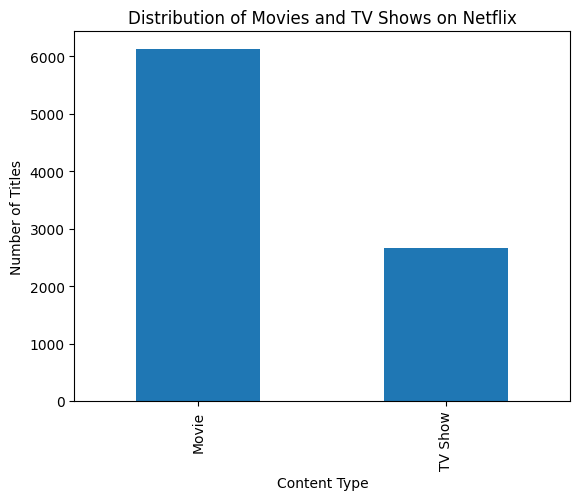

In [16]:
content=netflix["type"].value_counts()
content
content.plot(kind="bar")
plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

### Insight

Movies represent the majority of Netflix's catalog compared to TV Shows. This suggests that Netflix's content library has historically contained a larger collection of movie-based content.

## 2. Content Release Trend Analysis

Question:
Which years contributed the highest number of released Netflix titles?

Analyzing release years helps understand whether Netflix's catalog mainly consists of recent content or older content.

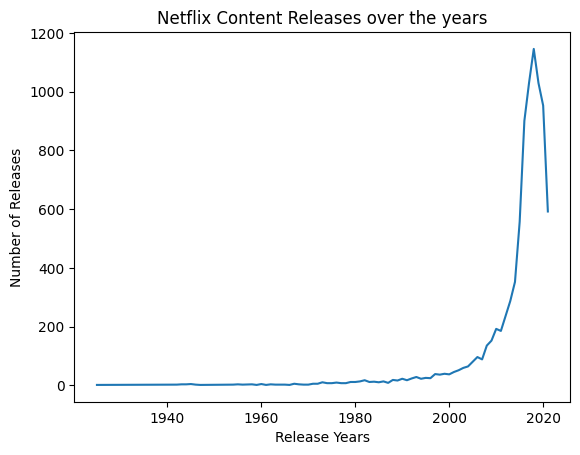

In [17]:
year_count=netflix["release_year"].value_counts().sort_index()
year_count.plot(kind="line")
plt.title("Netflix Content Releases over the years")
plt.xlabel("Release Years")
plt.ylabel("Number of Releases")
plt.show()

### Insight

Netflix's catalog mainly consists of newer content, with a major increase in titles released after 2010. This suggests Netflix focuses heavily on modern content to match current audience preferences.

## 3. Genre Analysis

### Question
What are the most common content genres available on Netflix?

### Purpose
Analyzing genres helps us understand the type of content Netflix focuses on and the variety of content offered to its audience.

Since a single Netflix title can belong to multiple genres, the genre values need to be separated before analysis to count each genre individually.

In [18]:
genre=netflix["listed_in"].str.split(", ").explode()
genre

0                  Documentaries
1         International TV Shows
1                      TV Dramas
1                   TV Mysteries
2                 Crime TV Shows
                  ...           
8805    Children & Family Movies
8805                    Comedies
8806                      Dramas
8806        International Movies
8806            Music & Musicals
Name: listed_in, Length: 19300, dtype: object

In [19]:
top10_genre=genre.value_counts().head(10)
top10_genre

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

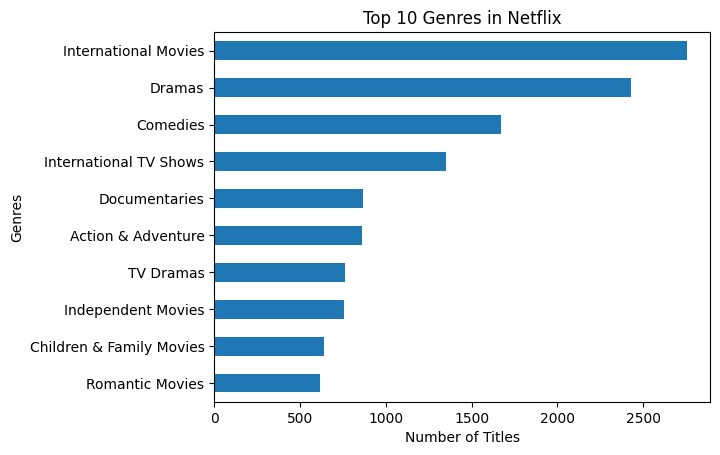

In [20]:
top10_genre.sort_values().plot(kind="barh")
plt.title("Top 10 Genres in Netflix")
plt.ylabel("Genres")
plt.xlabel("Number of Titles")
plt.show()

### Insight

International Movies, Dramas, and Comedies are the most common genres in Netflix's catalog. This indicates that Netflix focuses heavily on globally appealing and story-driven content, helping the platform attract audiences from different regions and preferences.

## 4. Audience Rating Analysis

### Question
Which audience categories does Netflix mainly target through its content?

### Purpose
Analyzing content ratings helps identify Netflix's target audience strategy by understanding whether the platform focuses more on kids, family-friendly content, teenagers, or mature audiences.

In [21]:
netflix["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'Unknown', 'TV-Y7-FV', 'UR'],
      dtype=object)

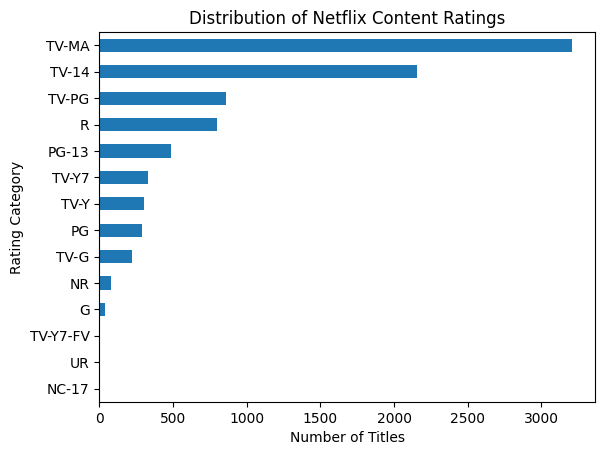

In [22]:
known_rating=netflix[netflix["rating"]!="Unknown"]
rating_count=known_rating["rating"].value_counts()
rating_count.sort_values().plot(kind="barh")
plt.title("Distribution of Netflix Content Ratings")
plt.ylabel("Rating Category")
plt.xlabel("Number of Titles")
plt.show()

### Insight

Mature audience ratings such as TV-MA represent a large portion of Netflix's catalog. This suggests that Netflix's content library is strongly focused on adult-oriented content compared to children or family-focused categories.

## 5. Country Contribution Analysis

### Question
Which countries contribute the most content to Netflix's catalog?

### Purpose
Analyzing countries helps understand the geographical distribution of Netflix's content and identify the major content-producing regions.

Since a single title can be associated with multiple countries, the country values need to be separated before counting individual country contributions.

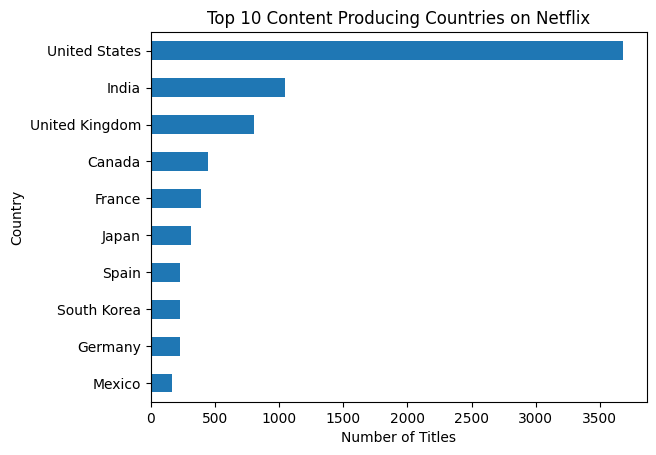

In [23]:
known_countries=netflix[netflix["country"]!="Unknown"]
countries=known_countries["country"].str.split(", ").explode()
top_countries=countries.value_counts().head(10)
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

### Insight

The United States contributes the largest amount of content in Netflix's catalog, followed by countries such as India and the United Kingdom.

This indicates that Netflix's content library has strong representation from major entertainment-producing regions while also maintaining a diverse collection of international content.

## 6. Duration Analysis

### Question
What is the typical duration pattern of Netflix movies?

### Purpose
Analyzing duration helps understand the length characteristics of Netflix content.

Since Movies use minutes and TV Shows use seasons, they need to be analyzed separately to avoid incorrect comparisons.

In [24]:
movies=netflix[netflix["type"]=="Movie"]
movie_duration = movies["duration"].str.replace(" min","").astype(int)
movie_duration.mean()

np.float64(99.57718668407311)

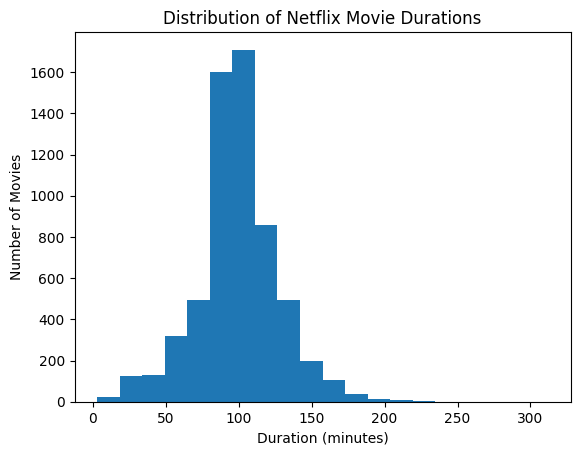

In [25]:
plt.hist(movie_duration,bins=20)

plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [26]:
movie_duration.describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

### Insight

Most Netflix movies are concentrated around the 80-120 minute duration range, indicating that Netflix's movie catalog mainly consists of standard feature-length films.

Only a small portion of movies exceed 150 minutes, showing that extremely long movies are less common in the catalog.

# Final Conclusion

This project analyzed Netflix's content catalog to understand content strategy patterns across content type, release years, genres, audience ratings, countries, and movie durations.

## Key Findings

- Netflix's catalog contains a larger proportion of Movies compared to TV Shows.
- Most titles in the catalog are from recent years, showing a preference toward modern content.
- International Movies, Dramas, and Comedies are the most common genres, indicating a focus on globally appealing and story-driven content.
- Mature audience content represents a major portion of Netflix's catalog.
- The United States contributes the highest amount of content, followed by other major entertainment markets.
- Most Netflix movies follow standard feature-length durations.

## Recommendations

- Expand family-friendly content categories to create a more balanced catalog for different audience groups.
- Include more classic and older titles to improve content variety.
- Continue investing in international and diverse genres to maintain a globally appealing catalog.